Uses envelope data to predict number of terms needed in each region.

In [1]:
import sys
from pathlib import Path
HERE = Path.cwd().resolve()
up1_path = str((HERE / ".." ).resolve())
up2_path = str((HERE / ".." / ".." ).resolve())
data_prefix = str((HERE / ".." / "i-region-convergence").resolve())
for pathstr in [up1_path, up2_path]:
  if pathstr not in sys.path:
      sys.path.insert(0, pathstr)

from helpers import *
import numpy as np
from prediction_evaluators import *

In [2]:
def unshielded(cf):
  if len(cf["d"]) < 3: return True
  for i in range(2, len(cf["d"])):
    if (cf["h"] - cf["d"][i]) < (cf["h"] - cf["d"][1]): return False
  return True

def filter_unshielded(cfs):
  return [cf for cf in cfs if unshielded(cf)]

def filter_converged(cfs):
  return [cf for cf in cfs if (max(cf[cf["m0s"][0]]["convergence point 0.01 am"],  cf[cf["m0s"][0]]["convergence point 0.01 dp"]) < 150)]

In [3]:
file4 = data_prefix + "/innermost-region/data/predetermined-2.pkl"
f4_data = open_pkl_file(file4)
generate_convergence_data(f4_data, [0.01])
generate_log_data(f4_data)
f4_data = filter_converged(f4_data)

low_rr = lambda cf : (cf["h"]-cf["d"][1])/(cf["h"]-cf["d"][0]) <= 0.8
high_rr = lambda cf : (cf["h"]-cf["d"][1])/(cf["h"]-cf["d"][0]) > 1

f4_data_low = [cf for cf in f4_data if low_rr(cf)]
f4_data_mid = [cf for cf in f4_data if not(low_rr(cf) or high_rr(cf))]
f4_data_high = [cf for cf in f4_data if high_rr(cf)]
f4_data_substep = f4_data_low + f4_data_high

In [4]:
def inner_model_1_cutoff(cutoff):
  def model_vars(vars, a1, a2, a3, a4, a5, a6):
    hmdr, right_ratio = vars
    alpha = (a1 + a2 * hmdr) * (right_ratio < cutoff) + (a3 + a4 * hmdr) * (right_ratio >= cutoff)
    beta = (a5 * hmdr) * (right_ratio < cutoff) + (a6 * hmdr) * (right_ratio >= cutoff)
    return alpha, beta
  
  variables_used = ["(h-d)/radwidth", "(h-d_out)/(h-d)"]
  return model_vars, variables_used

def inner_model_1_cutoff_variants(cutoff):
  inner_model, variables_used= inner_model_1_cutoff(cutoff)
  fit_model, cf_params_to_alpha_beta, err_from_nmk_model, nmk_from_err_model = get_model_variants(innermost_vars_cf, variables_used, inner_model)
  return variables_used, fit_model, cf_params_to_alpha_beta, err_from_nmk_model, nmk_from_err_model

def inner_weighted_fit_hmdr_rr_only(cfs, hydro, model, guess, nmk_max = 150, underweight = 1):
  return fit_inner_model_weighted(cfs, hydro, model, guess, ["(h-d)/radwidth", "(h-d_out)/(h-d)"], nmk_max = nmk_max, underweight = underweight)


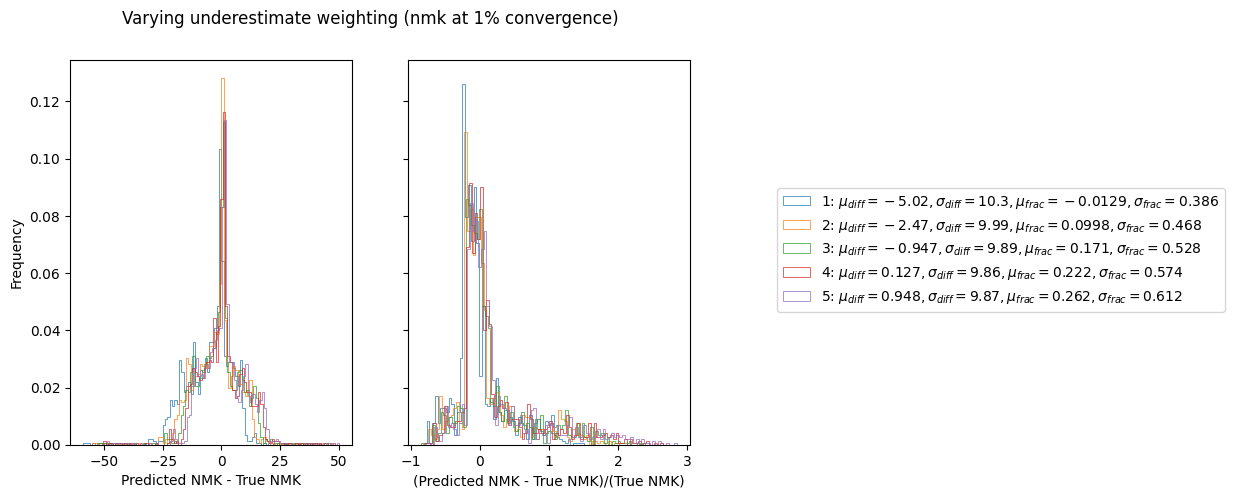

Sample size: 1420


In [5]:
variables_used, fit_model, cf_params_to_alpha_beta, err_from_nmk_model, nmk_from_err_model = inner_model_1_cutoff_variants(1)
cfs, hydro = f4_data, "am"
params_dict= {}
underweight_lst = [1, 2, 3, 4, 5]
for underweight in underweight_lst:
  params, res = inner_weighted_fit_hmdr_rr_only(cfs, hydro, fit_model, (1.44, 0.03, 1.44, 0.03, 0.2, 0.03), underweight = underweight)
  key = str(underweight)
  params_dict[key] = (nmk_from_err_model, params)
statpack = compare_nmk_distributions(cfs, hydro, params_dict, 0.01, title = "Varying underestimate weighting (nmk at 1% convergence)")


underweight = 1


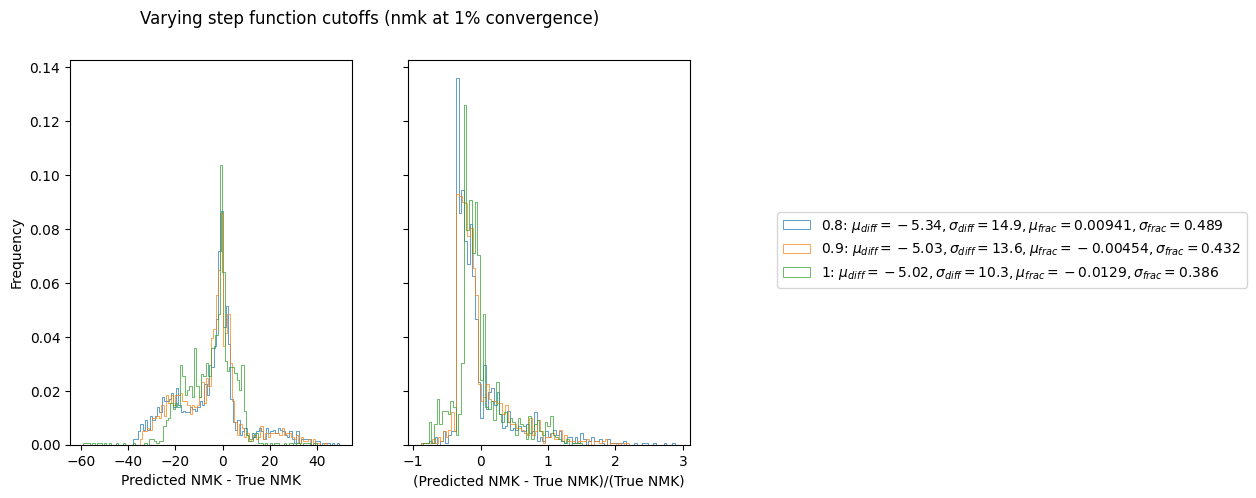

Sample size: 1420


In [6]:
cfs, hydro = f4_data, "am"
params_dict= {}
cutoffs = [0.8, 0.9, 1]
for cutoff in cutoffs:
  variables_used, fit_model, cf_params_to_alpha_beta, err_from_nmk_model, nmk_from_err_model = inner_model_1_cutoff_variants(cutoff)
  params, res = inner_weighted_fit_hmdr_rr_only(cfs, hydro, fit_model, (1.44, 0.03, 1.44, 0.03, 0.2, 0.03), underweight = 1)
  key = str(cutoff)
  params_dict[key] = (nmk_from_err_model, params)
print("underweight = 1")
statpack = compare_nmk_distributions(cfs, hydro, params_dict, 0.01, title = "Varying step function cutoffs (nmk at 1% convergence)")

underweight = 1


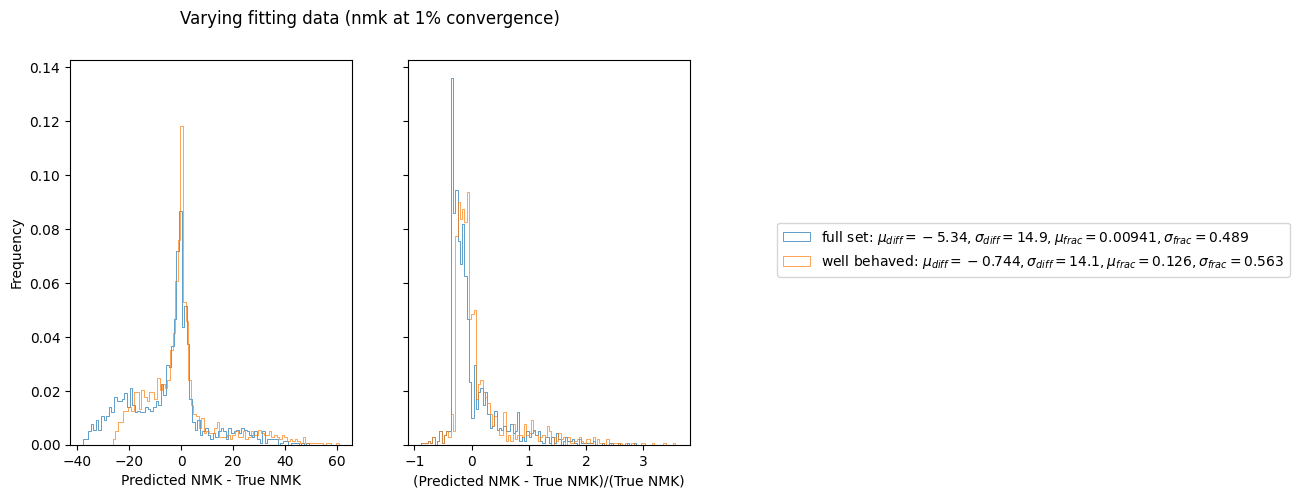

Sample size: 1420


In [7]:
cfs, hydro = f4_data, "am"
params_dict= {}
data_sets = {"full set" : f4_data, "well behaved" : f4_data_substep}
variables_used, fit_model, cf_params_to_alpha_beta, err_from_nmk_model, nmk_from_err_model = inner_model_1_cutoff_variants(0.8)
for key in data_sets.keys():
  params, res = inner_weighted_fit_hmdr_rr_only(data_sets[key], hydro, fit_model, (1.44, 0.03, 1.44, 0.03, 0.2, 0.03), underweight = 1)
  params_dict[key] = (nmk_from_err_model, params)
print("underweight = 1")
statpack = compare_nmk_distributions(cfs, hydro, params_dict, 0.01, title = "Varying fitting data (nmk at 1% convergence)")

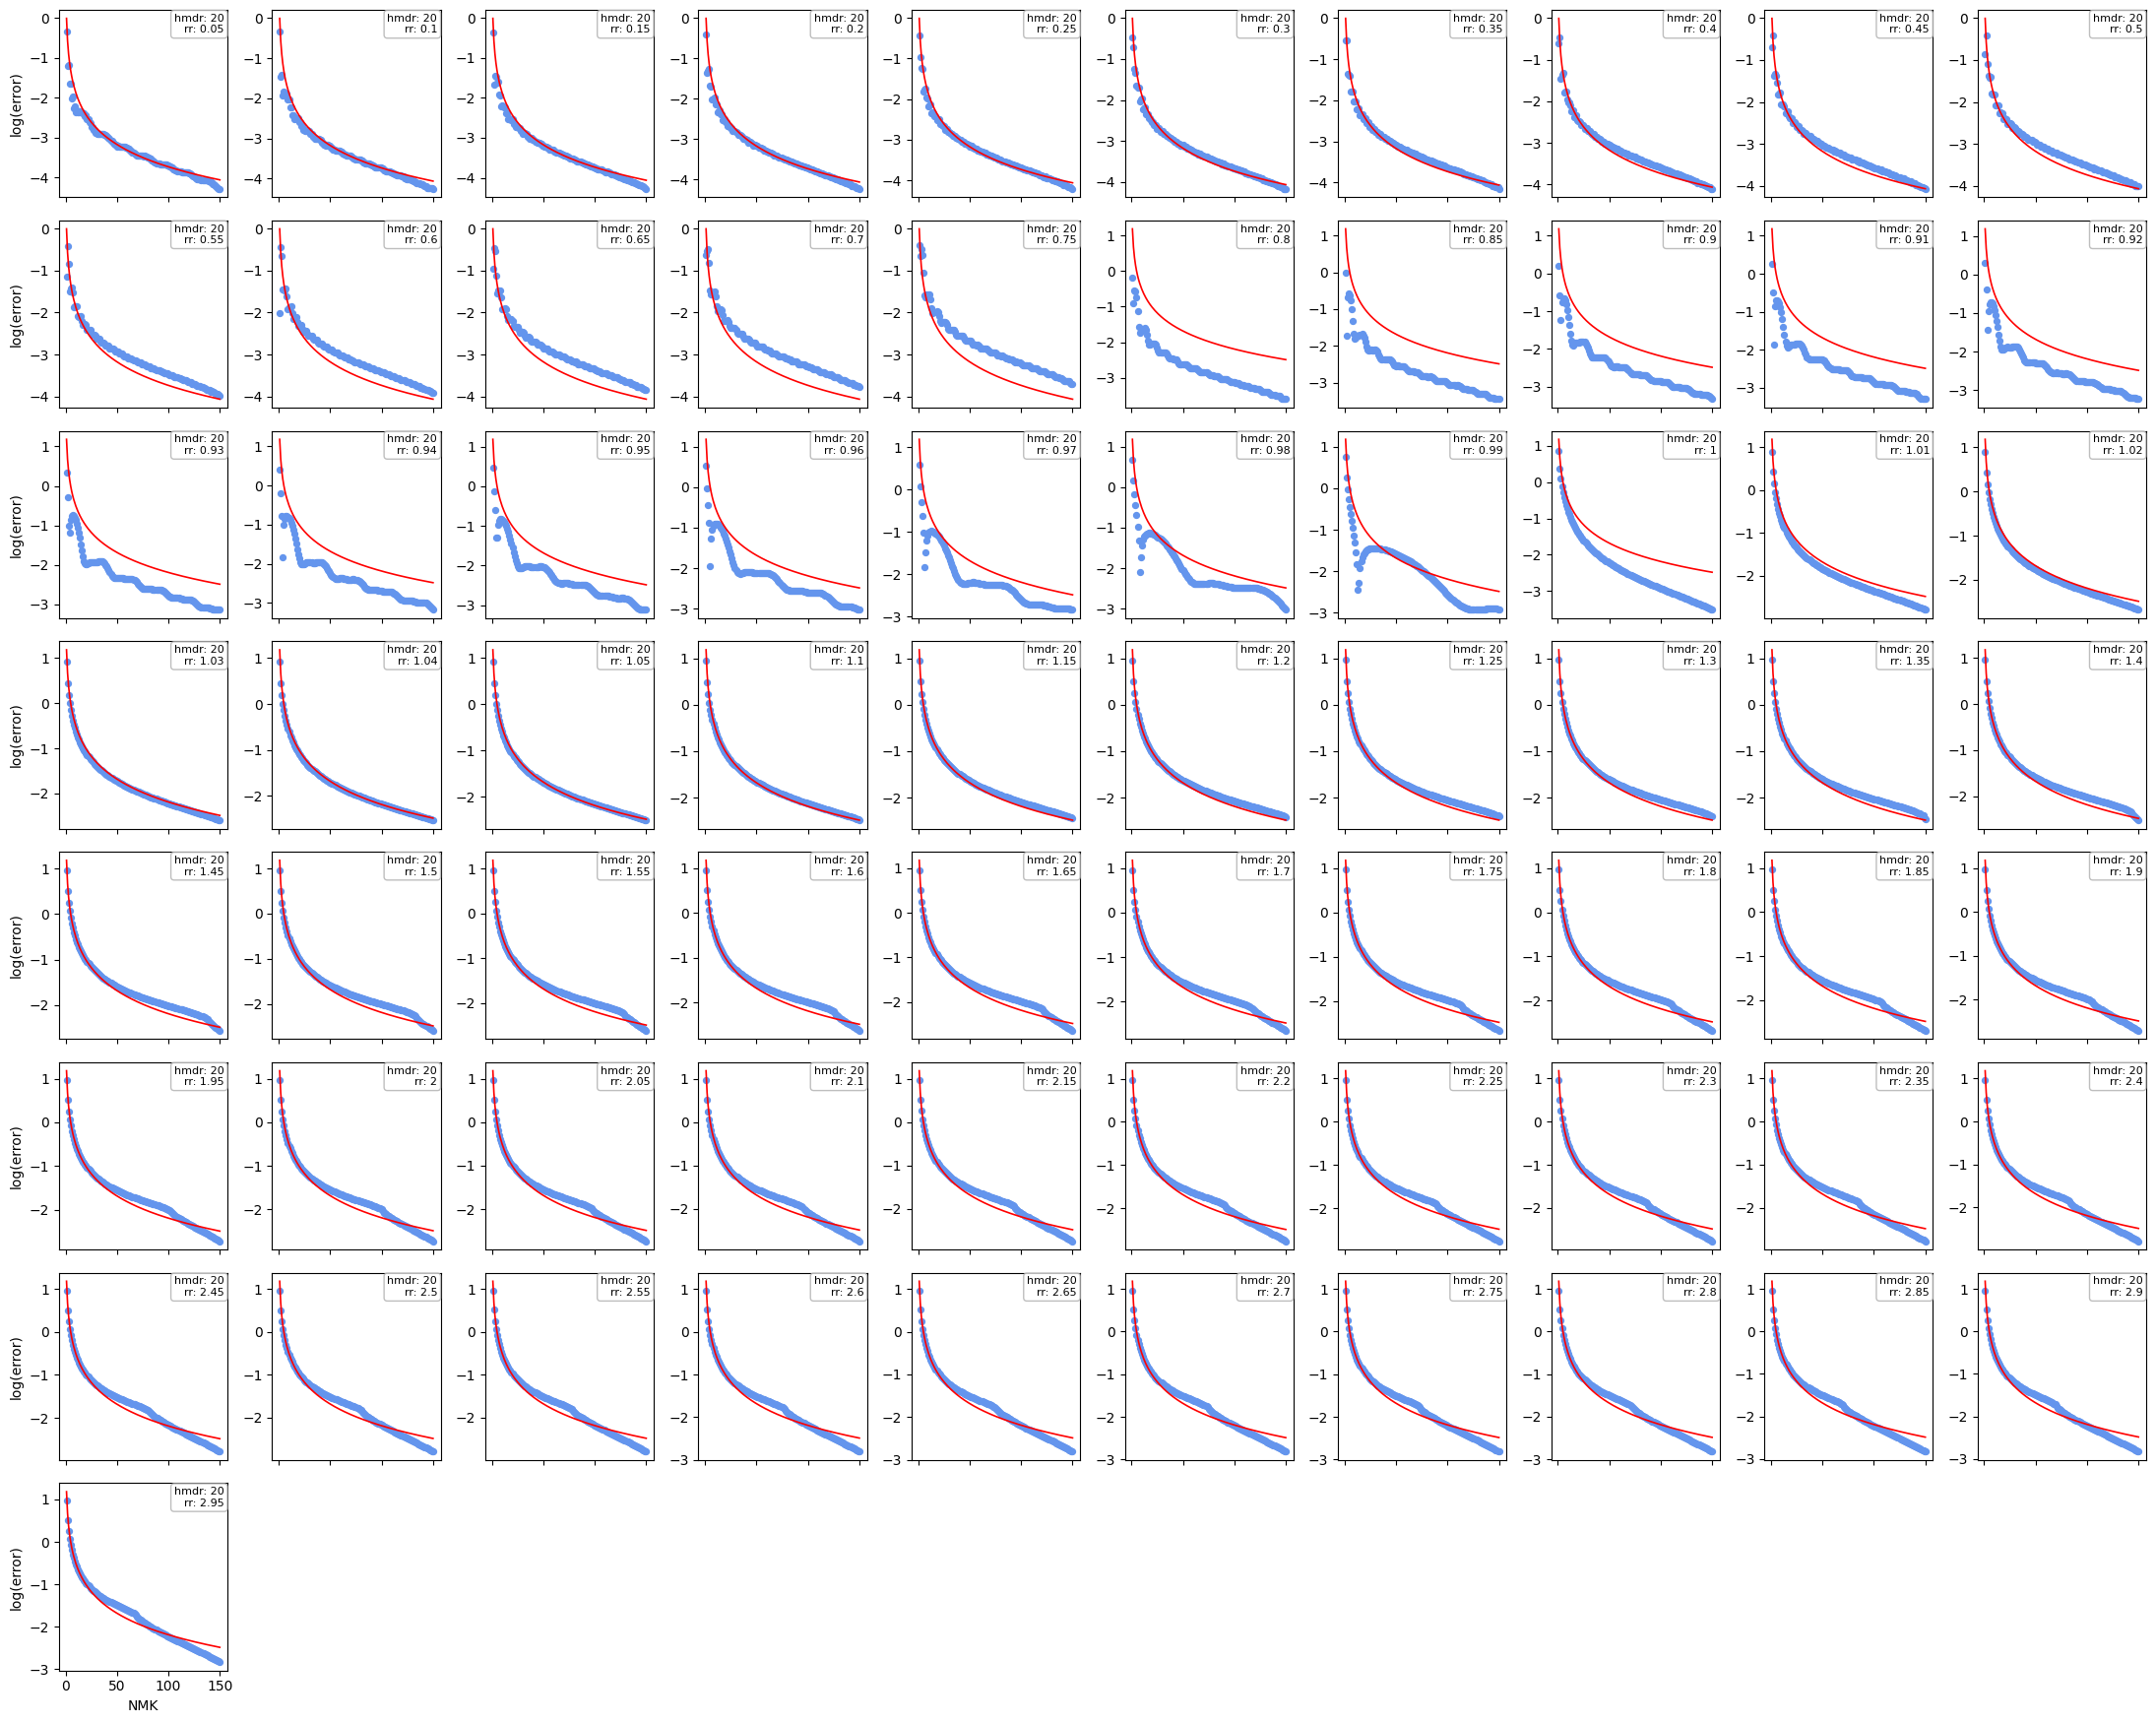

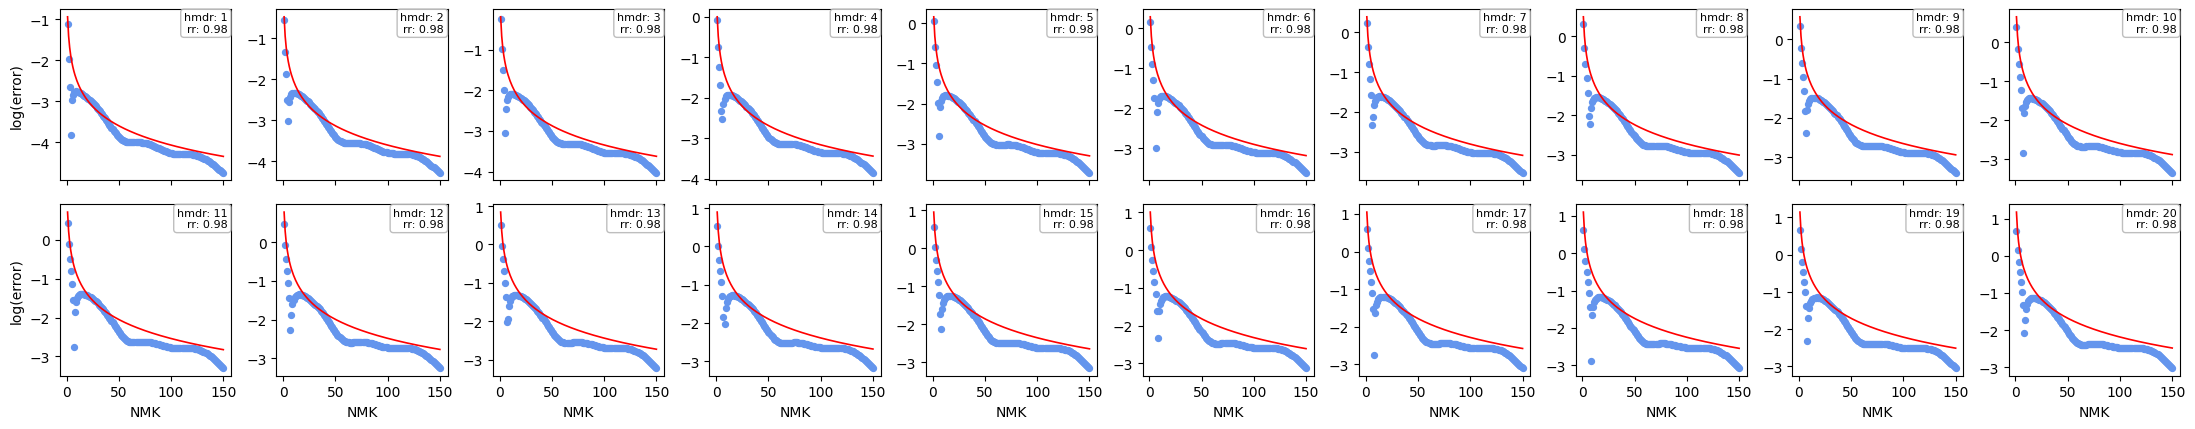

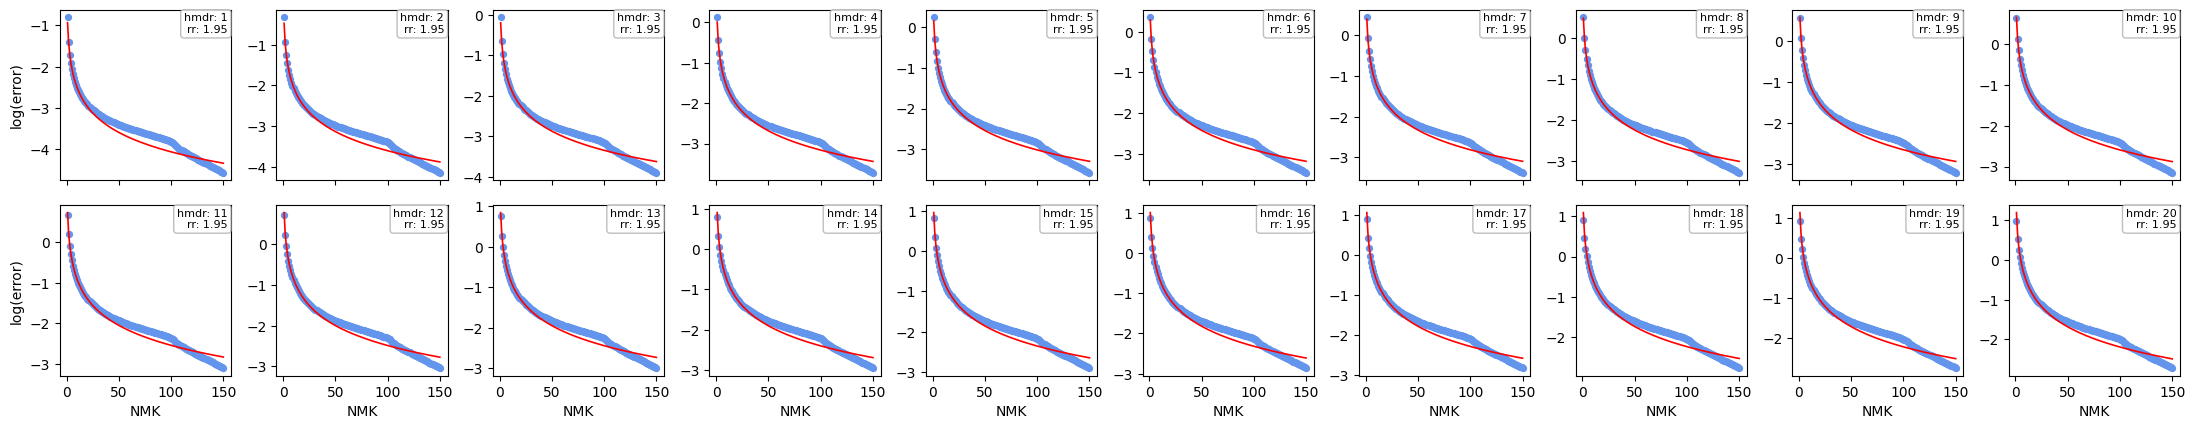

In [8]:
summary_fs = {"hmdr" : lambda cf : (cf["h"]-cf["d"][0])/cf["a"][0],
              "rr" : lambda cf : (cf["h"]-cf["d"][1])/(cf["h"]-cf["d"][0])}

variables_used, fit_model, cf_params_to_alpha_beta, err_from_nmk_model, nmk_from_err_model = inner_model_1_cutoff_variants(0.8)
params, res = inner_weighted_fit_hmdr_rr_only(f4_data_substep, "am", fit_model, (1.44, 0.03, 1.44, 0.03, 0.2, 0.03), underweight = 1)
err_from_nmk_full = lambda nmk : np.log10(err_from_nmk_model(nmk, *params))

sub_data = [f4_data[i] for i in range(19, 1420, 20)]
compare_model_curves(sub_data, extractf_am, model_wrapper(lambda cf : cf_params_to_alpha_beta(cf, *params)), summary_fs)
sub_data = [f4_data[i] for i in range(500, 520)]
compare_model_curves(sub_data, extractf_am, model_wrapper(lambda cf : cf_params_to_alpha_beta(cf, *params)), summary_fs)
sub_data = [f4_data[i] for i in range(1000, 1020)]
compare_model_curves(sub_data, extractf_am, model_wrapper(lambda cf : cf_params_to_alpha_beta(cf, *params)), summary_fs)

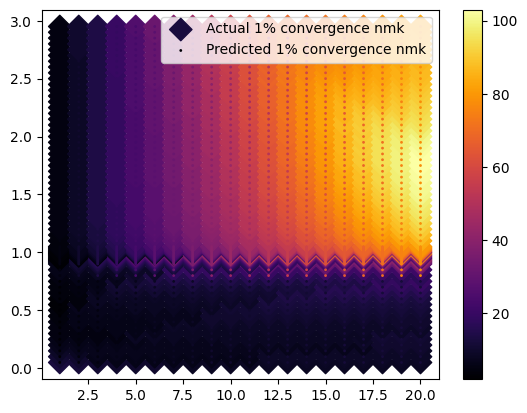

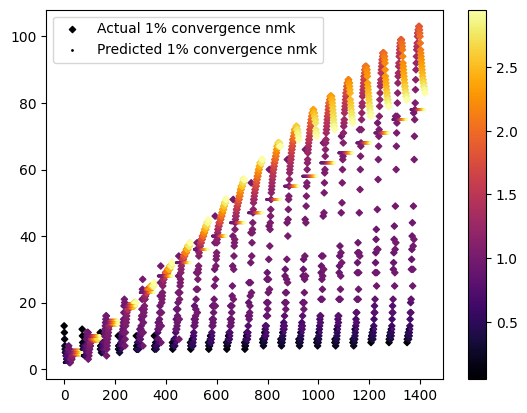

In [9]:
def color_diff_plot(data, vars_to_alpha_beta_model):
  sorted_data = sorted(sorted(data, key = lambda cf:(cf["h"]-cf["d"][0])/(cf["a"][0])), key=lambda cf:(cf["h"]-cf["d"][1])/(cf["h"]-cf["d"][0]))
  data = evaluate_many_precomputed_geoms(sorted_data, vars_to_alpha_beta_model, vars_to_alpha_beta_model, 0.01)
  right_ratios = [(cf["h"]-cf["d"][1])/(cf["h"]-cf["d"][0]) for cf in sorted_data]
  hmdrs = [(cf["h"]-cf["d"][0])/(cf["a"][0]) for cf in sorted_data]
  true_nmks = [cf["am nmk actual"] for cf in data]
  predicted_nmks = [cf["am nmk predicted"] for cf in data]
  v_min = min(min(true_nmks), min(predicted_nmks))
  v_max = max(max(true_nmks), max(predicted_nmks))
  plt.scatter(hmdrs, right_ratios, label = "Actual 1% convergence nmk", s=130, marker="D", c=true_nmks, cmap="inferno", vmin = v_min, vmax = v_max)
  plt.scatter(hmdrs, right_ratios, label = "Predicted 1% convergence nmk", s=1, marker="o",c=predicted_nmks,cmap="inferno", vmin = v_min, vmax = v_max)
  plt.legend()
  plt.colorbar()
  plt.show()

def nmk_on_y_plot(data, vars_to_alpha_beta_model):
  sorted_data = sorted(data, key = lambda cf:(cf["h"]-cf["d"][0])/(cf["a"][0]))
  data = evaluate_many_precomputed_geoms(sorted_data, vars_to_alpha_beta_model, vars_to_alpha_beta_model, 0.01)
  right_ratios = [(cf["h"]-cf["d"][1])/(cf["h"]-cf["d"][0]) for cf in sorted_data]
  hmdrs = [(cf["h"]-cf["d"][0])/(cf["a"][0]) for cf in sorted_data]
  true_nmks = [cf["am nmk actual"] for cf in data]
  predicted_nmks = [cf["am nmk predicted"] for cf in data]
  xs = range(len(true_nmks))
  plt.scatter(xs, true_nmks, label = "Actual 1% convergence nmk", s=10, marker="D", c=right_ratios, cmap="inferno")
  plt.scatter(xs, predicted_nmks, label = "Predicted 1% convergence nmk", s=1, marker="o",c=right_ratios,cmap="inferno")
  plt.legend()
  plt.colorbar()
  plt.show()
  
variables_used, fit_model, cf_params_to_alpha_beta, err_from_nmk_model, nmk_from_err_model = inner_model_1_cutoff_variants(0.8)
params, res = inner_weighted_fit_hmdr_rr_only(f4_data_substep, "am", fit_model, (1.44, 0.03, 1.44, 0.03, 0.2, 0.03), underweight = 1)

vars_to_alpha_beta_model = lambda cf : cf_params_to_alpha_beta(cf, *params)

color_diff_plot(f4_data, vars_to_alpha_beta_model)
nmk_on_y_plot(f4_data, vars_to_alpha_beta_model)

In [ ]:
assert False
# All past this point is very disorganized, ignore.

In [ ]:
file1 = data_prefix + "/innermost-region/data/predetermined-8.pkl"
file2 = data_prefix + "/middle-region/data/predetermined-4.pkl"
file3 = data_prefix + "/outermost-region/data/predetermined-2.pkl"

f1_data = open_pkl_file(file1)
for pset in f1_data:
  generate_convergence_data(pset, [0.01])
  generate_log_data(pset)

file5 = data_prefix + "/innermost-region/data/predetermined-5.pkl"
file6 = data_prefix + "/innermost-region/data/predetermined-6.pkl"
file7 = data_prefix + "/innermost-region/data/random-innermost.pkl"
f5_data = [filter_unshielded(cfs) for cfs in open_pkl_file(file5)]
f6_data = [filter_unshielded(cfs) for cfs in open_pkl_file(file6)]
for pset in f5_data:
  generate_convergence_data(pset, [0.01])
  generate_log_data(pset)
for pset in f6_data:
  generate_convergence_data(pset, [0.01])
  generate_log_data(pset)

f7_data = open_pkl_file(file7)
generate_convergence_data(f7_data, [0.01])
f7_data = filter_unshielded(filter_converged(f7_data))
_ = generate_log_data(f7_data)

In [ ]:
xs, ys, alphas, betas = [], [], [], []

for cf in f4_data:
  popt, pcov, r2_val, r2_under = fit_parameters(cf, cf["m0s"][0], "am", print_params = False)
  alpha, beta = popt
  xs.append((cf["h"] - cf["d"][0])/cf["a"][0])
  ys.append((cf["h"] - cf["d"][1])/(cf["h"] - cf["d"][0]))
  alphas.append(alpha)
  betas.append(beta)

plot_3tuples_2d(np.column_stack((xs, ys, alphas)), xlabel = "(h-d)/radwidth", ylabel = "(h-d1)/(h-d0)", clabel = "alpha", title = "innermost added mass alphas")
plot_3tuples_2d(np.column_stack((xs, ys, betas)), xlabel = "(h-d)/radwidth", ylabel = "(h-d1)/(h-d0)", clabel = "beta", title = "innermost added mass betas")

In [ ]:
def fit_and_print1(data):
  fit_and_print(data, inner_am_model1, (1.5, 0.02, 0.2))

def fit_and_print2(data):
  fit_and_print(data, inner_am_model2, (1.5, 0.02, 0.2, 0.02, 1))

fit_and_print1(f1_data[1] + f1_data[2] + f1_data[4])
# fit_and_print1(f1_data[1] + f1_data[2])
# fit_and_print1(f1_data[1] + f1_data[4])
# fit_and_print1(f1_data[2] + f1_data[4])
fit_and_print1(f4_data)
fit_and_print1(f5_data[3])
fit_and_print1(f6_data[0] + f6_data[1] + f6_data[2])
fit_and_print1(f7_data[:28] + f7_data[29:]) # what's up with this? maybe generation was bad
print("trying to compensate for the differences is difficult — see model 2")

# fit_and_print2(f1_data[1] + f1_data[2] + f1_data[4])
# fit_and_print2(f4_data)
# fit_and_print2(f5_data[3])
# fit_and_print2(f6_data[0] + f6_data[1] + f6_data[2])
# fit_and_print2(f1_data[1] + f1_data[2] + f4_data + f5_data[3] + f6_data[0] + f6_data[1] + f6_data[2])

In [ ]:
def inner_dp_model1(vars, alpha_base, alpha_high, lower_slope, upper_slope):
  nmk, hmdr, right_ratio, rad_ratio, m0_dist = vars
  offset = upper_slope - lower_slope
  alpha_offset = alpha_high - alpha_base
  beta = hmdr * (lower_slope + offset * (right_ratio > 1))
  alpha = alpha_base + alpha_offset * (right_ratio < 1)
  return - alpha * np.log(nmk/beta)

def fit_and_print(data, model, guess):
  popt, pcov = fit_inner_model(data, "dp", model, guess, nmk_max = 150)
  print(popt)
#  print(pcov)

def fit_and_print1(data):
  fit_and_print(data, inner_dp_model1, (1.5, -0.015, 0.025, 0.05))

fit_and_print1(f1_data[1] + f1_data[2] + f1_data[4])

In [ ]:
fit_and_print1(f7_data[:28] + f7_data[29:])

In [ ]:
xs, ys, alphas, betas = [], [], [], []

for cf in (f7_data[:28] + f7_data[29:]):
  popt, pcov, r2_val, r2_under = fit_parameters(cf, cf["m0s"][0], "am", print_params = False)
  alpha, beta = popt
  if beta < 4:
    xs.append((cf["h"] - cf["d"][0])/cf["a"][0])
    ys.append((cf["h"] - cf["d"][1])/(cf["h"] - cf["d"][0]))
    alphas.append(alpha)
    betas.append(beta)

plot_3tuples_2d(np.column_stack((xs, ys, alphas)), xlabel = "(h-d)/radwidth", ylabel = "(h-d1)/(h-d0)", clabel = "alpha", title = "innermost added mass alphas")
plot_3tuples_2d(np.column_stack((xs, ys, betas)), xlabel = "(h-d)/radwidth", ylabel = "(h-d1)/(h-d0)", clabel = "beta", title = "innermost added mass betas")

In [ ]:
popt, pcov = fit_inner_model(f7_data, "am", inner_am_model1, (1.5, 0.02, 0.2), nmk_max = 150)
params = [ab_inner_am_model1(cf, cf["m0s"][0], *popt) for cf in f7_data]
xs = [(cf["h"] - cf["d"][0])/cf["a"][0] for cf in f7_data]
ys = [(cf["h"] - cf["d"][1])/(cf["h"] - cf["d"][0]) for cf in f7_data]
alphas = [entry[0] for entry in params]
betas = [entry[1] for entry in params]

plot_3tuples_2d(np.column_stack((xs, ys, alphas)), xlabel = "(h-d)/radwidth", ylabel = "(h-d1)/(h-d0)", clabel = "alpha", title = "innermost added mass alphas")
plot_3tuples_2d(np.column_stack((xs, ys, betas)), xlabel = "(h-d)/radwidth", ylabel = "(h-d1)/(h-d0)", clabel = "beta", title = "innermost added mass betas")